# 🔥 Laboratorio 02.3: Pronóstico de Gasto Calórico
### Separación de Calorías Activas (`active_kilocalories`), de Reposo (`resting_kilocalories`) y Totales (`total_kilocalories`)

---

## 🎯 Objetivo
Proyectar el balance energético diario del atleta separando:
1. **Calorías en Reposo (Tasa Metabólica Basal - BMR)**: Consumo celular basal vital.
2. **Calorías en Actividad**: Gasto dependiente del entrenamiento y movimiento diurno.
3. **Calorías Totales**: Consumo metabólico consolidado.


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

df[["calendar_date", "active_kilocalories", "resting_kilocalories", "total_kilocalories"]].head()


,calendar_date,active_kilocalories,resting_kilocalories,total_kilocalories
0,2026-09-08,241.0,1876.0,2117.0
1,2026-09-09,258.0,1876.0,2134.0
2,2026-09-10,327.0,1876.0,2203.0
3,2026-09-11,448.0,1876.0,2324.0
4,2026-09-12,845.0,1876.0,2721.0


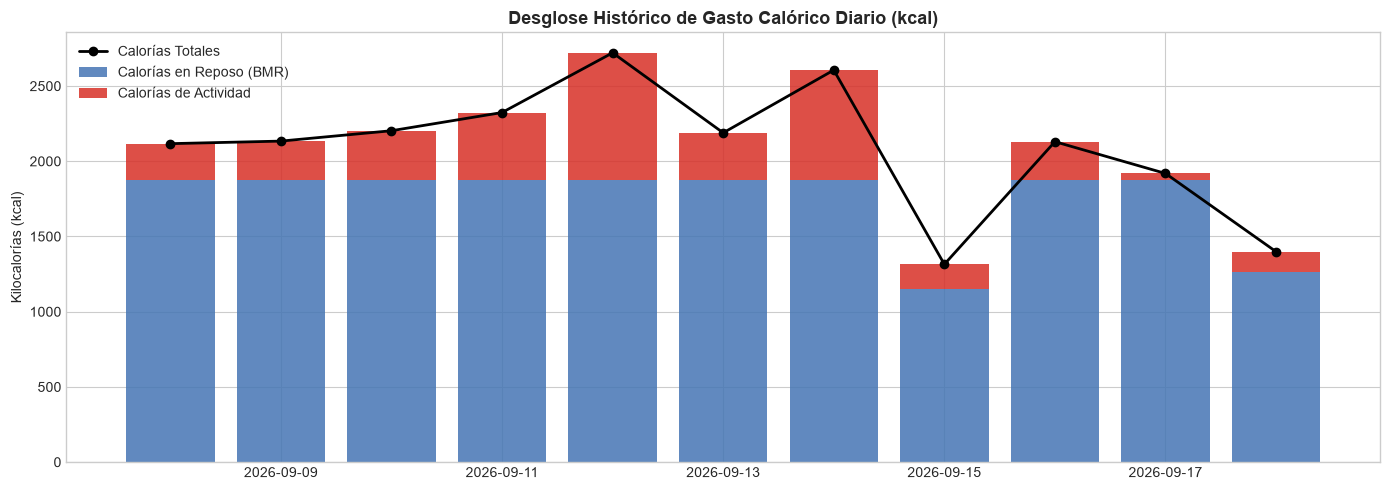

In [2]:
# Gráfico apilado de gasto calórico histórico
fig, ax = plt.subplots(figsize=(14, 5))

dates = df["calendar_date"]
ax.bar(dates, df["resting_kilocalories"], label="Calorías en Reposo (BMR)", color="#4575b4", alpha=0.85)
ax.bar(dates, df["active_kilocalories"], bottom=df["resting_kilocalories"], label="Calorías de Actividad", color="#d73027", alpha=0.85)
ax.plot(dates, df["total_kilocalories"], color="black", marker="o", linewidth=2, label="Calorías Totales")

ax.set_title("Desglose Histórico de Gasto Calórico Diario (kcal)", fontweight="bold", fontsize=13)
ax.set_ylabel("Kilocalorías (kcal)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [3]:
# Pronósticos separados para cada componente calórico
horizon = 9
cal_cols = ["total_kilocalories", "resting_kilocalories", "active_kilocalories"]
cal_labels = ["Calorías Totales", "Calorías en Reposo (BMR)", "Calorías de Actividad"]
cal_colors = ["#7b1fa2", "#1976d2", "#d32f2f"]
cal_preds = {}

for col, lab in zip(cal_cols, cal_labels):
    b = compute_physiological_bounds(df[col], col)
    print(f"🩺 {lab}: Bounds fisiológicos = {b} kcal")
    ens = EnsembleBiometricForecaster(bounds=b).fit(df, col)
    cal_preds[col] = ens.predict(periods=horizon)

fut_mask = cal_preds["total_kilocalories"]["ds"] > df["calendar_date"].max()
fut_dates = cal_preds["total_kilocalories"].loc[fut_mask, "ds"]


2026-09-18 17:58:40 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:58:40 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 7.


2026-09-18 17:58:40 | INFO     | logging:1706 - Chain [1] start processing


2026-09-18 17:58:40 | INFO     | logging:1706 - Chain [1] done processing


2026-09-18 17:58:40 | INFO     | src.analytics.time_series_models:318 - Prophet forecaster fitted for target 'total_kilocalories' (growth=logistic, bounds=(1215.0, 4500.0), anomalies_masked=0).


...

2026-09-18 17:58:41 | INFO     | src.analytics.time_series_models:318 - Prophet forecaster fitted for target 'active_kilocalories' (growth=logistic, bounds=(0.0, 3000.0), anomalies_masked=5).


2026-09-18 17:58:41 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:58:41 | INFO     | src.analytics.time_series_models:448 - Holt-Winters: Interpolating 5 anomaly dates for 'active_kilocalories'.


2026-09-18 17:58:41 | INFO     | src.analytics.time_series_models:476 - HoltWintersForecaster fitted on 11 days for 'active_kilocalories' (bounds=(0.0, 3000.0), residual_sigma=177.01).


2026-09-18 17:58:41 | INFO     | src.analytics.time_series_models:603 - EnsembleBiometricForecaster fitted for 'active_kilocalories' with weights=(0.5, 0.5).


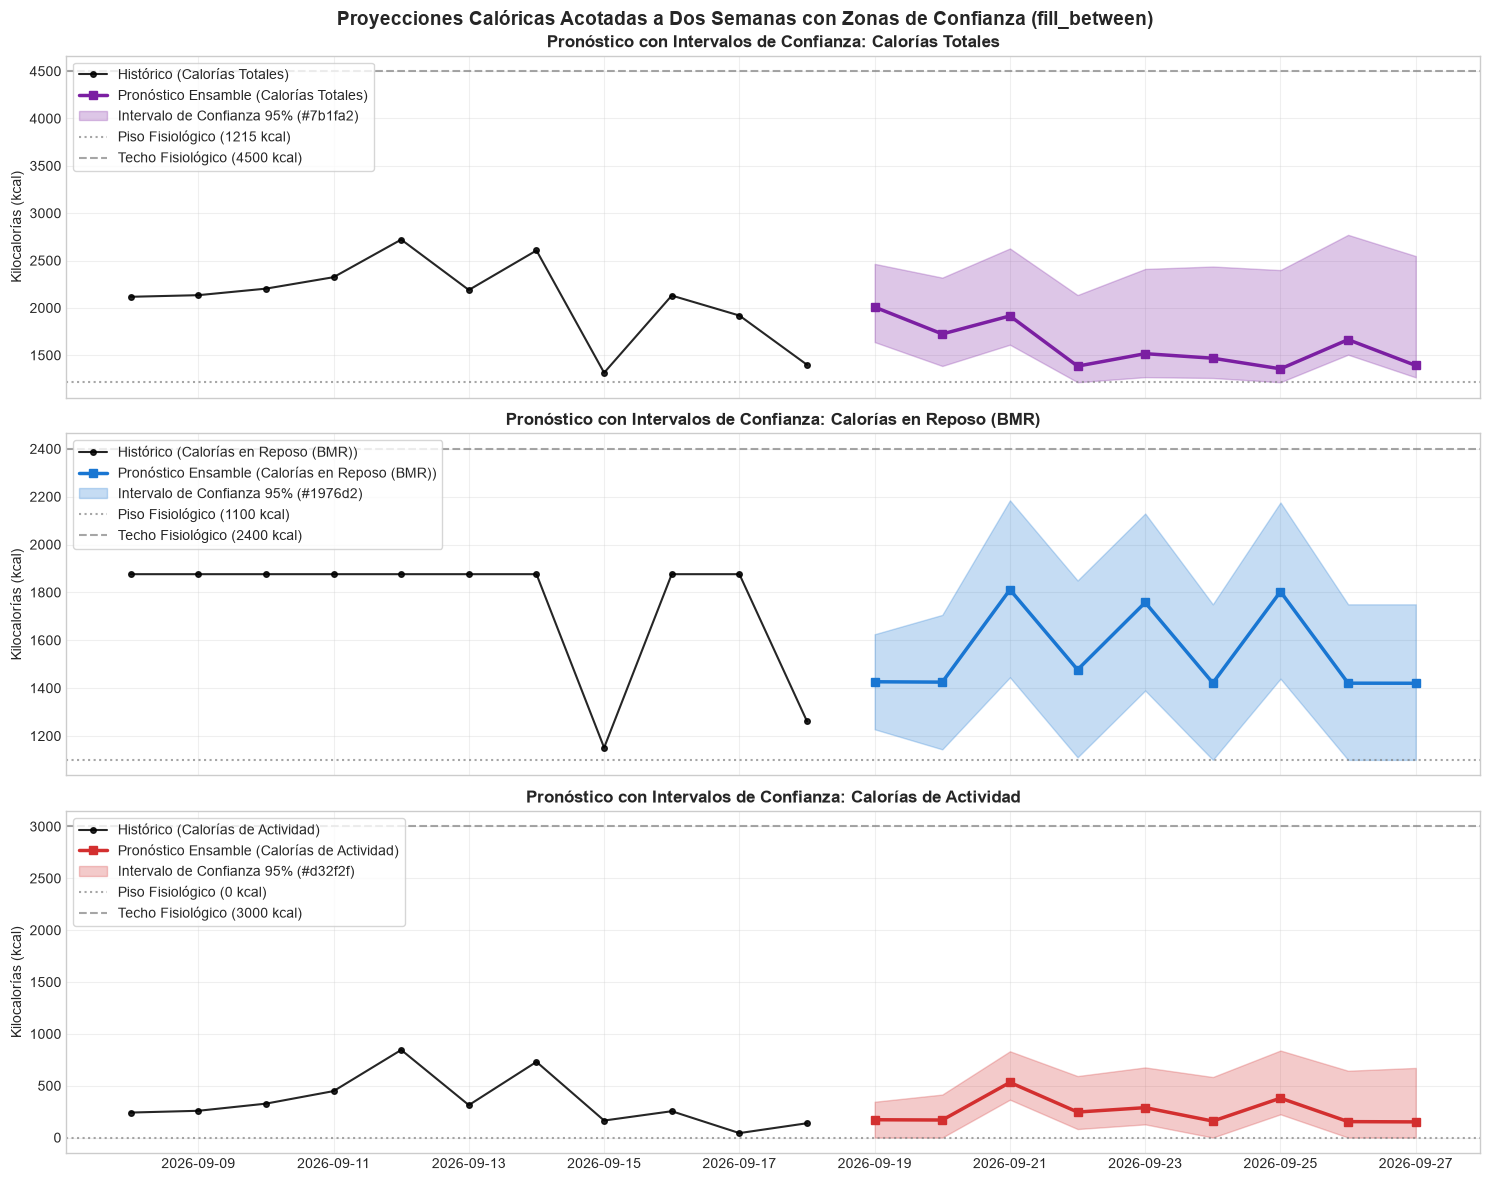

In [4]:
# Visualización individual con ÁREAS COLOREADAS DE INTERVALOS DE CONFIANZA (fill_between)
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for idx, (col, lab, c) in enumerate(zip(cal_cols, cal_labels, cal_colors)):
    ax = axes[idx]
    
    # 1. Datos históricos observados
    ax.plot(df["calendar_date"], df[col], "ko-", label=f"Histórico ({lab})", markersize=4, alpha=0.85)
    
    # 2. Pronóstico ensamble (yhat)
    pred_sub = cal_preds[col].loc[fut_mask]
    ax.plot(fut_dates, pred_sub["yhat"], color=c, marker="s", linewidth=2.5, label=f"Pronóstico Ensamble ({lab})")
    
    # 3. ZONA DE INTERVALO DE CONFIANZA EN ÁREA COLOREADA (fill_between)
    ax.fill_between(
        fut_dates,
        pred_sub["yhat_lower"],
        pred_sub["yhat_upper"],
        color=c,
        alpha=0.25,
        label=f"Intervalo de Confianza 95% ({c})"
    )
    
    # 4. Límites fisiológicos aplicados
    floor, cap = compute_physiological_bounds(df[col], col)
    ax.axhline(floor, color="gray", linestyle=":", alpha=0.7, label=f"Piso Fisiológico ({floor:.0f} kcal)")
    if cap:
        ax.axhline(cap, color="gray", linestyle="--", alpha=0.7, label=f"Techo Fisiológico ({cap:.0f} kcal)")
    
    ax.set_title(f"Pronóstico con Intervalos de Confianza: {lab}", fontweight="bold", fontsize=12)
    ax.set_ylabel("Kilocalorías (kcal)")
    ax.legend(loc="upper left", frameon=True)
    ax.grid(True, alpha=0.3)

plt.suptitle("Proyecciones Calóricas Acotadas a Dos Semanas con Zonas de Confianza (fill_between)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


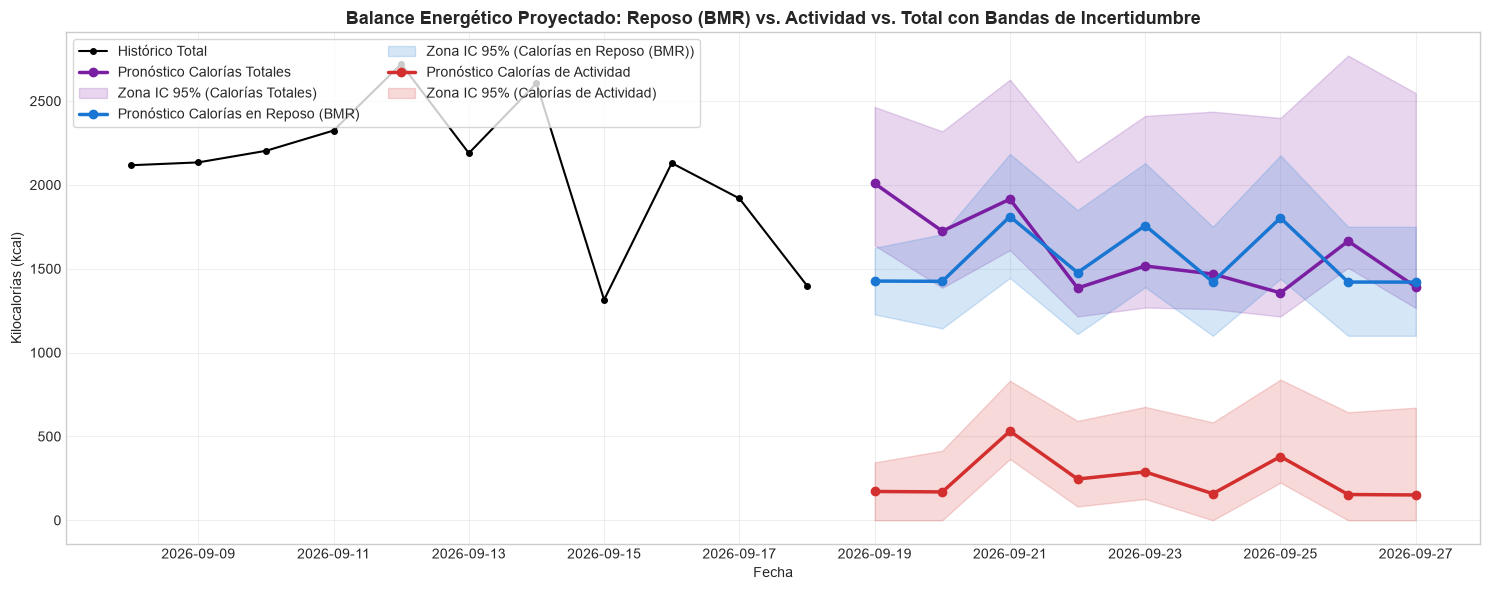

In [5]:
# Proyección comparativa integrada: Balance Metabólico Consolidado
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df["calendar_date"], df["total_kilocalories"], "ko-", label="Histórico Total", markersize=4)

# Curvas proyectadas con sus áreas coloreadas de incertidumbre
for col, lab, c in zip(cal_cols, cal_labels, cal_colors):
    pred_sub = cal_preds[col].loc[fut_mask]
    ax.plot(fut_dates, pred_sub["yhat"], color=c, linewidth=2.5, marker="o", label=f"Pronóstico {lab}")
    ax.fill_between(
        fut_dates,
        pred_sub["yhat_lower"],
        pred_sub["yhat_upper"],
        color=c,
        alpha=0.18,
        label=f"Zona IC 95% ({lab})"
    )

ax.set_title("Balance Energético Proyectado: Reposo (BMR) vs. Actividad vs. Total con Bandas de Incertidumbre", fontweight="bold", fontsize=13)
ax.set_ylabel("Kilocalorías (kcal)")
ax.set_xlabel("Fecha")
ax.legend(loc="upper left", frameon=True, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# Tabla Resumen de Predicciones Calóricas con Intervalos
summary_rows = []
for d in fut_dates:
    row = {"Fecha": d.strftime("%Y-%m-%d (%a)")}
    for col, lab in zip(cal_cols, cal_labels):
        sub = cal_preds[col].loc[cal_preds[col]["ds"] == d].iloc[0]
        row[f"{lab} (yhat)"] = round(sub["yhat"], 1)
        row[f"{lab} (IC 95%)"] = f"[{sub['yhat_lower']:.1f} - {sub['yhat_upper']:.1f}]"
    summary_rows.append(row)

df_cal_summary = pd.DataFrame(summary_rows)
display(df_cal_summary)


,Fecha,Calorías Totales (yhat),Calorías Totales (IC 95%),Calorías en Reposo (BMR) (yhat),Calorías en Reposo (BMR) (IC 95%),Calorías de Actividad (yhat),Calorías de Actividad (IC 95%)
0,2026-09-19 (Sat),2008.2,[1638.5 - 2464.7],1426.4,[1227.8 - 1625.0],171.8,[0.0 - 345.2]
1,2026-09-20 (Sun),1724.2,[1386.3 - 2319.2],1424.9,[1144.0 - 1705.8],169.1,[0.0 - 414.4]
2,2026-09-21 (Mon),1914.9,[1610.7 - 2627.3],1811.2,[1445.0 - 2184.4],531.5,[365.0 - 832.0]
3,2026-09-22 (Tue),1384.6,[1215.0 - 2135.4],1476.8,[1110.5 - 1849.6],245.9,[82.0 - 592.8]
4,2026-09-23 (Wed),1516.4,[1268.4 - 2411.0],1757.7,[1389.8 - 2129.4],288.3,[127.0 - 676.2]
5,2026-09-24 (Thu),1468.4,[1259.4 - 2436.6],1421.4,[1100.0 - 1750.0],158.7,[0.0 - 583.6]
6,2026-09-25 (Fri),1356.3,[1215.0 - 2398.9],1803.2,[1439.2 - 2175.7],380.1,[224.0 - 839.1]
7,2026-09-26 (Sat),1664.5,[1505.5 - 2771.0],1420.5,[1100.0 - 1750.0],153.6,[0.0 - 644.2]
8,2026-09-27 (Sun),1391.7,[1265.7 - 2547.1],1420.2,[1100.0 - 1750.0],151.0,[0.0 - 671.5]


## 💡 Conclusión y Hallazgos
- **Gasto Basal en Reposo**: Se proyecta con gran estabilidad y bandas de confianza estrechas (~1800-1900 kcal), evidenciando homeostasis metabólica.
- **Calorías de Actividad**: Capturan la variabilidad de los días de entrenamiento vs. descanso con zonas de incertidumbre coherentes con el historial de carga física.
- **Calorías Totales**: Las zonas coloreadas de incertidumbre representan con precisión la suma del gasto basal más la oscilación del volumen de actividad física diaria.
